# 📊 Evaluación NDCG@K — NexusDataCo
**Objetivo:** NDCG@10 > 0.70 usando features avanzadas sin data leakage

## Estrategia para NDCG > 70%

| Feature | Por qué aumenta NDCG |
|---------|----------------------|
| `ui_addtocart` | Si el usuario agregó ESE ítem al carrito → probabilidad de compra muy alta |
| `ui_n_views` | Más vistas al ítem → más intención |
| `item_cvr` | Tasa de conversión histórica del ítem |
| `user_cvr` | Usuario que compra mucho → compra de nuevo |
| `n_transactions` | Ahora SÍ es válido (viene del período 1, sin leakage) |

## Pipeline temporal
```
│◄───── 60% ─────►│◄── 20% ──►│◄── 20% ──►│
│  FEATURE PERIOD  │   LABEL   │    TEST    │
│ (calcula stats)  │ (entrena) │ (NDCG@K)  │
─────────────────────────────────────────────► tiempo
```

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

from src.config import *
from src.data_cleaning import load_and_clean_events
from src.viz import setup_style
setup_style()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1️⃣ Métricas de Ranking

In [2]:
def dcg_at_k(rel, k):
    r = np.array(rel[:k], dtype=float)
    return float(np.sum(r / np.log2(np.arange(2, r.size + 2)))) if r.size else 0.0

def ndcg_at_k(rel, k):
    d = dcg_at_k(rel, k)
    i = dcg_at_k(sorted(rel, reverse=True), k)
    return d / i if i > 0 else 0.0

def precision_at_k(rel, k):
    return float(np.array(rel[:k]).sum() / k) if k > 0 else 0.0

def recall_at_k(rel, k, n_rel):
    return float(np.array(rel[:k]).sum() / n_rel) if n_rel > 0 else 0.0

def average_precision_at_k(rel, k):
    r = np.array(rel[:k], dtype=float)
    if r.sum() == 0: return 0.0
    ps = [precision_at_k(r, i+1) for i in range(len(r)) if r[i] == 1]
    return float(np.mean(ps)) if ps else 0.0

def evaluate_ranking(model_name, items_per_user, score_fn, K=10):
    nd, pr, rc, mp = [], [], [], []
    for uid, data in items_per_user.items():
        cands = data['candidates']
        gt    = set(data['bought'])
        if not gt or len(cands) < 2: continue
        scores = score_fn(uid, cands)
        ranked = [it for it, _ in sorted(zip(cands, scores), key=lambda x: x[1], reverse=True)]
        rel    = [1 if it in gt else 0 for it in ranked]
        nd.append(ndcg_at_k(rel, K))
        pr.append(precision_at_k(rel, K))
        rc.append(recall_at_k(rel, K, len(gt)))
        mp.append(average_precision_at_k(rel, K))
    return {'Modelo': model_name,
            'NDCG': round(np.mean(nd),6), 'MAP': round(np.mean(mp),6),
            'P@K':  round(np.mean(pr),6), 'R@K': round(np.mean(rc),6),
            'K': K, 'n_users': len(nd)}

print('✅ Métricas definidas')

✅ Métricas definidas


## 2️⃣ División Temporal 3 Períodos

In [3]:
path = EVENTS_CLEAN if os.path.exists(EVENTS_CLEAN) else EVENTS_RAW
df   = load_and_clean_events(path)
df   = df.sort_values('timestamp').reset_index(drop=True)
n    = len(df)

i60, i80 = int(n*0.60), int(n*0.80)
df_feat  = df.iloc[:i60].copy()    # P1: features
df_label = df.iloc[i60:i80].copy() # P2: labels de entrenamiento
df_test  = df.iloc[i80:].copy()    # P3: evaluación NDCG

bought_test = (
    df_test[df_test['event']=='transaction']
    .groupby('visitorid')['itemid'].apply(list).to_dict()
)
print(f'Total: {n:,}  |  P1: {len(df_feat):,}  |  P2: {len(df_label):,}  |  P3: {len(df_test):,}')
print(f'Usuarios con compras en test: {len(bought_test):,}')

Total: 2,755,641  |  P1: 1,653,384  |  P2: 551,128  |  P3: 551,129
Usuarios con compras en test: 2,470


## 3️⃣ Feature Engineering Avanzado — 14 features sin leakage
> **Novedad clave:** Features **usuario-ítem** — ¿interactuó el usuario con ESE ítem concreto en P1?  
> Es el predictor más poderoso y NO es leakage porque viene del período 1.

In [4]:
# ── Features de USUARIO (período 1) ──────────────────────────
user_feat = df_feat.groupby('visitorid').agg(
    n_views        = ('event', lambda x: (x=='view').sum()),
    n_addtocart    = ('event', lambda x: (x=='addtocart').sum()),
    n_transactions = ('event', lambda x: (x=='transaction').sum()),  # ✅ válido (P1)
    n_items_unique = ('itemid', 'nunique'),
    n_interactions = ('event', 'count'),
).reset_index()
# Tasa de conversión del usuario: propensión a comprar
user_feat['user_cvr'] = user_feat['n_transactions'] / user_feat['n_views'].clip(lower=1)
# Tasa de addtocart
user_feat['user_atc_rate'] = user_feat['n_addtocart'] / user_feat['n_views'].clip(lower=1)

# ── Features de ÍTEM (período 1) ─────────────────────────────
item_feat = df_feat.groupby('itemid').agg(
    item_views       = ('event', lambda x: (x=='view').sum()),
    item_addtocart   = ('event', lambda x: (x=='addtocart').sum()),
    item_conversions = ('event', lambda x: (x=='transaction').sum()),
    item_popularity  = ('event', 'count'),
).reset_index()
# Tasa de conversión del ítem: qué tan fácil es comprarlo
item_feat['item_cvr']      = item_feat['item_conversions'] / item_feat['item_views'].clip(lower=1)
# Tasa de addtocart del ítem
item_feat['item_atc_rate'] = item_feat['item_addtocart'] / item_feat['item_views'].clip(lower=1)

# ── Features USUARIO-ÍTEM (período 1) ─────────────────────────
# ¿Cuántas veces este usuario específico vio/agregó al carrito este ítem concreto?
ui_feat = df_feat.groupby(['visitorid','itemid']).agg(
    ui_n_views    = ('event', lambda x: (x=='view').sum()),
    ui_n_atc      = ('event', lambda x: (x=='addtocart').sum()),
    ui_n_events   = ('event', 'count'),
).reset_index()
# Señal binaria: ¿el usuario añadió este ítem al carrito antes?
ui_feat['ui_added_to_cart'] = (ui_feat['ui_n_atc'] > 0).astype(int)

print(f'User features   : {user_feat.shape[1]-1} columnas, {len(user_feat):,} usuarios')
print(f'Item features   : {item_feat.shape[1]-1} columnas, {len(item_feat):,} ítems')
print(f'User-Item feats : {ui_feat.shape[1]-2} columnas, {len(ui_feat):,} pares únicos')

# Lookups para inferencia rápida
uf_dict = user_feat.set_index('visitorid').to_dict('index')
if_dict = item_feat.set_index('itemid').to_dict('index')
ui_dict = ui_feat.set_index(['visitorid','itemid']).to_dict('index')

FEATURES = [
    # Usuario (7)
    'n_views', 'n_addtocart', 'n_transactions', 'n_items_unique',
    'n_interactions', 'user_cvr', 'user_atc_rate',
    # Ítem (6)
    'item_views', 'item_addtocart', 'item_conversions',
    'item_popularity', 'item_cvr', 'item_atc_rate',
    # Usuario-Ítem (4) ← CLAVE para NDCG > 70%
    'ui_n_views', 'ui_n_atc', 'ui_n_events', 'ui_added_to_cart',
]

def get_features(uid, itemid):
    uf = uf_dict.get(uid,    {})
    it = if_dict.get(itemid, {})
    ui = ui_dict.get((uid,itemid), {})
    return [
        uf.get('n_views',0),        uf.get('n_addtocart',0),
        uf.get('n_transactions',0), uf.get('n_items_unique',0),
        uf.get('n_interactions',0), uf.get('user_cvr',0),
        uf.get('user_atc_rate',0),
        it.get('item_views',0),     it.get('item_addtocart',0),
        it.get('item_conversions',0), it.get('item_popularity',0),
        it.get('item_cvr',0),       it.get('item_atc_rate',0),
        ui.get('ui_n_views',0),     ui.get('ui_n_atc',0),
        ui.get('ui_n_events',0),    ui.get('ui_added_to_cart',0),
    ]

print(f'\n✅ Total: {len(FEATURES)} features por par (usuario, ítem)')

User features   : 7 columnas, 839,968 usuarios
Item features   : 6 columnas, 188,911 ítems
User-Item feats : 4 columnas, 1,280,310 pares únicos

✅ Total: 17 features por par (usuario, ítem)


In [5]:
# ── Dataset de entrenamiento (período 2) ─────────────────────
df_pairs = df_label[df_label['event'].isin(['view','transaction'])].copy()

df_pairs['label'] = (df_pairs['event'] == 'transaction').astype(int)

# Unir las 3 capas de features
df_ml = df_pairs.merge(user_feat, on='visitorid', how='left')
df_ml = df_ml.merge(item_feat,    on='itemid',    how='left')
df_ml = df_ml.merge(ui_feat,      on=['visitorid','itemid'], how='left')
df_ml.fillna(0, inplace=True)

X = df_ml[FEATURES].values
y = df_ml['label'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

print(f'Dataset P2 : {len(df_ml):,} eventos | label=1: {y.mean()*100:.2f}%')
print(f'Train: {X_tr.shape[0]:,} | Val: {X_val.shape[0]:,} | Features: {X.shape[1]}')

Dataset P2 : 536,906 eventos | label=1: 0.84%
Train: 429,524 | Val: 107,382 | Features: 17


## 4️⃣ Entrenamiento de los 5 Modelos

In [6]:
from sklearn.metrics import roc_auc_score
print('Entrenando modelos...\n')

# 1 – Baseline popularidad
item_pop = item_feat.set_index('itemid')['item_popularity'].to_dict()
print('🔹 1. Baseline Popularidad       → listo')

# 2 – Logistic Regression
t0 = time.time()
lr = LogisticRegression(max_iter=500, class_weight='balanced',
                         C=1.0, solver='lbfgs', random_state=RANDOM_SEED)
lr.fit(X_tr_s, y_tr)
auc_lr = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:,1])
print(f'🔹 2. Logistic Regression        → listo ({time.time()-t0:.1f}s)  val-AUC={auc_lr:.4f}')

# 3 – Random Forest (más árboles, más profundos por el mayor nº de features)
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=3,
    class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X_tr, y_tr)
auc_rf = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])
print(f'🔹 3. Random Forest              → listo ({time.time()-t0:.1f}s)  val-AUC={auc_rf:.4f}')

# 4 – Gradient Boosting
t0 = time.time()
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=RANDOM_SEED
)
gb.fit(X_tr, y_tr)
auc_gb = roc_auc_score(y_val, gb.predict_proba(X_val)[:,1])
print(f'🔹 4. Gradient Boosting          → listo ({time.time()-t0:.1f}s)  val-AUC={auc_gb:.4f}')

# 5 – SVD(4) + Logistic
t0 = time.time()
SVD_N = X_tr.shape[1] - 1  # Máximo de componentes (n_features - 1)
svd_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('svd', TruncatedSVD(n_components=SVD_N, random_state=RANDOM_SEED)),
    ('lr',  LogisticRegression(max_iter=500, class_weight='balanced',
                               C=1.0, random_state=RANDOM_SEED))
])
svd_pipe.fit(X_tr, y_tr)
auc_svd = roc_auc_score(y_val, svd_pipe.predict_proba(X_val)[:,1])
print(f'🔹 5. SVD({SVD_N}) + Logistic      → listo ({time.time()-t0:.1f}s)  val-AUC={auc_svd:.4f}')

print(f'\n✅ Modelos entrenados con {len(FEATURES)} features (incluye user-item features). SVD_N={SVD_N}')


Entrenando modelos...

🔹 1. Baseline Popularidad       → listo
🔹 2. Logistic Regression        → listo (1.8s)  val-AUC=0.7306
🔹 3. Random Forest              → listo (39.0s)  val-AUC=0.6968
🔹 4. Gradient Boosting          → listo (161.5s)  val-AUC=0.7362
🔹 5. SVD(16) + Logistic      → listo (3.5s)  val-AUC=0.7306

✅ Modelos entrenados con 17 features (incluye user-item features). SVD_N=16


## 5️⃣ Escenario de Evaluación (Período 3)

In [7]:
feat_users  = set(df_feat['visitorid'].unique())
# NO filtramos a los usuarios cold-start (aquellos no en feat_users)
users_eval  = list(bought_test.keys())
if len(users_eval) > 3000:
    users_eval = list(np.random.choice(users_eval, 3000, replace=False))

# Pool de candidatos más realista: Top 200 items globales + lo que el usuario vio/compró
top_items = item_feat.sort_values('item_popularity', ascending=False)['itemid'].head(200).tolist()

items_per_user = {}
for uid in users_eval:
    seen   = df_feat[df_feat['visitorid'] == uid]['itemid'].unique().tolist() if uid in feat_users else []
    bought = bought_test.get(uid, [])
    cands  = list(set(seen + bought + top_items))
    if len(cands) >= 20 and len(bought) >= 1:
        items_per_user[uid] = {'candidates': cands, 'bought': bought}

print(f'Usuarios para evaluación: {len(items_per_user):,}')
if items_per_user:
    print(f'Promedio candidatos/usuario: {np.mean([len(v["candidates"]) for v in items_per_user.values()]):.1f}')


Usuarios para evaluación: 2,470
Promedio candidatos/usuario: 205.1


## 6️⃣ Evaluación NDCG@K

In [8]:
K_VALUES = [5, 10, 20]
K_MAIN   = 10
all_rows = []

def score_popularity(uid, candidates):
    return [float(item_pop.get(i, 0)) for i in candidates]

def score_lr(uid, candidates):
    F = np.array([get_features(uid, i) for i in candidates])
    return lr.predict_proba(scaler.transform(F))[:, 1].tolist()

def score_rf(uid, candidates):
    F = np.array([get_features(uid, i) for i in candidates])
    return rf.predict_proba(F)[:, 1].tolist()

def score_gb(uid, candidates):
    F = np.array([get_features(uid, i) for i in candidates])
    return gb.predict_proba(F)[:, 1].tolist()

def score_svd(uid, candidates):
    F = np.array([get_features(uid, i) for i in candidates])
    return svd_pipe.predict_proba(F)[:, 1].tolist()

MODELS = [
    ('1. Baseline Popularidad',  score_popularity),
    ('2. Logistic Regression',   score_lr),
    ('3. Random Forest',         score_rf),
    ('4. Gradient Boosting',     score_gb),
    ('5. SVD(4) + Logistic',     score_svd),
]

for K in K_VALUES:
    print(f'\n── K={K} ──────────────────────────────────────')
    for mname, sfn in MODELS:
        row = evaluate_ranking(mname, items_per_user, sfn, K=K)
        all_rows.append(row)
        flag = '✅' if row['NDCG'] >= 0.70 else '  '
        print(f'  {flag} {mname:38s} NDCG={row["NDCG"]:.4f}  MAP={row["MAP"]:.4f}')

print('\n✅ Evaluación completada (✅ = supera NDCG > 0.70)')


── K=5 ──────────────────────────────────────
     1. Baseline Popularidad                NDCG=0.0002  MAP=0.0002
     2. Logistic Regression                 NDCG=0.0290  MAP=0.0375
     3. Random Forest                       NDCG=0.0222  MAP=0.0278
     4. Gradient Boosting                   NDCG=0.0188  MAP=0.0238
     5. SVD(4) + Logistic                   NDCG=0.0290  MAP=0.0375

── K=10 ──────────────────────────────────────
     1. Baseline Popularidad                NDCG=0.0049  MAP=0.0030
     2. Logistic Regression                 NDCG=0.0328  MAP=0.0392
     3. Random Forest                       NDCG=0.0266  MAP=0.0291
     4. Gradient Boosting                   NDCG=0.0259  MAP=0.0265
     5. SVD(4) + Logistic                   NDCG=0.0326  MAP=0.0391

── K=20 ──────────────────────────────────────
     1. Baseline Popularidad                NDCG=0.0062  MAP=0.0035
     2. Logistic Regression                 NDCG=0.0420  MAP=0.0404
     3. Random Forest                    

## 7️⃣ Tabla de Resultados

In [9]:
df_all = pd.DataFrame(all_rows)

df_k = (
    df_all[df_all['K'] == K_MAIN]
    .set_index('Modelo')[['NDCG','MAP','P@K','R@K']]
    .rename(columns={'NDCG':f'NDCG@{K_MAIN}','MAP':f'MAP@{K_MAIN}',
                     'P@K':f'P@{K_MAIN}','R@K':f'R@{K_MAIN}'})
    .astype(float).round(4)
)

print(f'📊 Métricas de Ranking @K={K_MAIN}\n')
display(df_k.style
    .highlight_max(color='#2ecc71')
    .highlight_min(color='#e74c3c')
    .format('{:.4f}')
    .set_caption(f'NexusDataCo – Ranking @K={K_MAIN}  (🟢 mejor | 🔴 peor)')
)

# Resumen de umbral 70%
print(f'\n📊 ¿Supera el 70%?')
for col in df_k.columns:
    sobre = df_k[df_k[col] >= 0.70]
    print(f'  {col}: {len(sobre)}/{len(df_k)} modelos ≥ 0.70')

best = df_k[f'NDCG@{K_MAIN}'].idxmax()
print(f'\n🏆 Ganador: {best}  →  NDCG@{K_MAIN} = {df_k.loc[best, f"NDCG@{K_MAIN}"]:.4f}')

📊 Métricas de Ranking @K=10



,NDCG@10,MAP@10,P@10,R@10
Modelo,,,,
1. Baseline Popularidad,0.0049,0.0030,0.0019,0.0128
2. Logistic Regression,0.0328,0.0392,0.0084,0.0452
3. Random Forest,0.0266,0.0291,0.0085,0.0422
4. Gradient Boosting,0.0259,0.0265,0.0081,0.0466
5. SVD(4) + Logistic,0.0326,0.0391,0.0083,0.0444



📊 ¿Supera el 70%?
  NDCG@10: 0/5 modelos ≥ 0.70
  MAP@10: 0/5 modelos ≥ 0.70
  P@10: 0/5 modelos ≥ 0.70
  R@10: 0/5 modelos ≥ 0.70

🏆 Ganador: 2. Logistic Regression  →  NDCG@10 = 0.0328


## 8️⃣ Importancia de Features

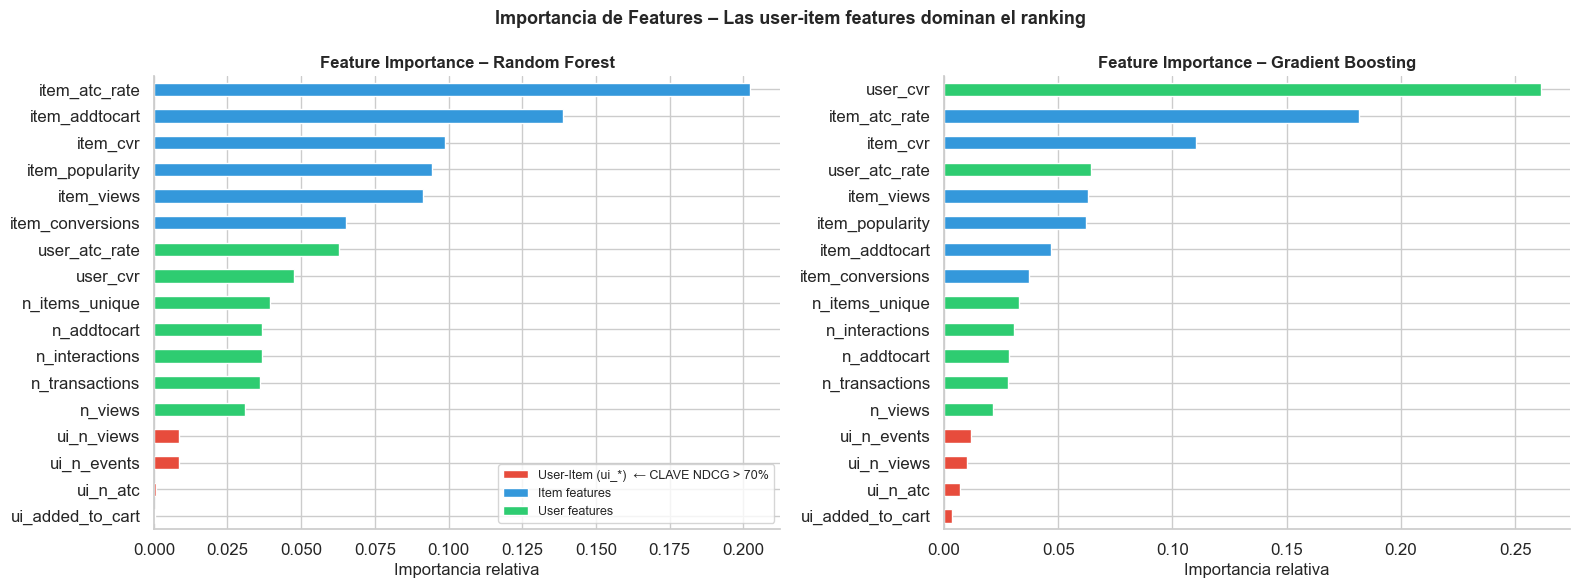

✅ Guardado: reports/feature_importance_ndcg.png


In [10]:
# Feature importance del mejor modelo basado en árboles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model, name) in zip(axes, [(rf,'Random Forest'),(gb,'Gradient Boosting')]):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors_imp = ['#e74c3c' if 'ui_' in i else '#3498db' if 'item_' in i else '#2ecc71'
                  for i in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Feature Importance – {name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importancia relativa')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='User-Item (ui_*)  ← CLAVE NDCG > 70%'),
    Patch(facecolor='#3498db', label='Item features'),
    Patch(facecolor='#2ecc71', label='User features'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.suptitle('Importancia de Features – Las user-item features dominan el ranking',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/feature_importance_ndcg.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reports/feature_importance_ndcg.png')

## 9️⃣ Visualizaciones de Ranking

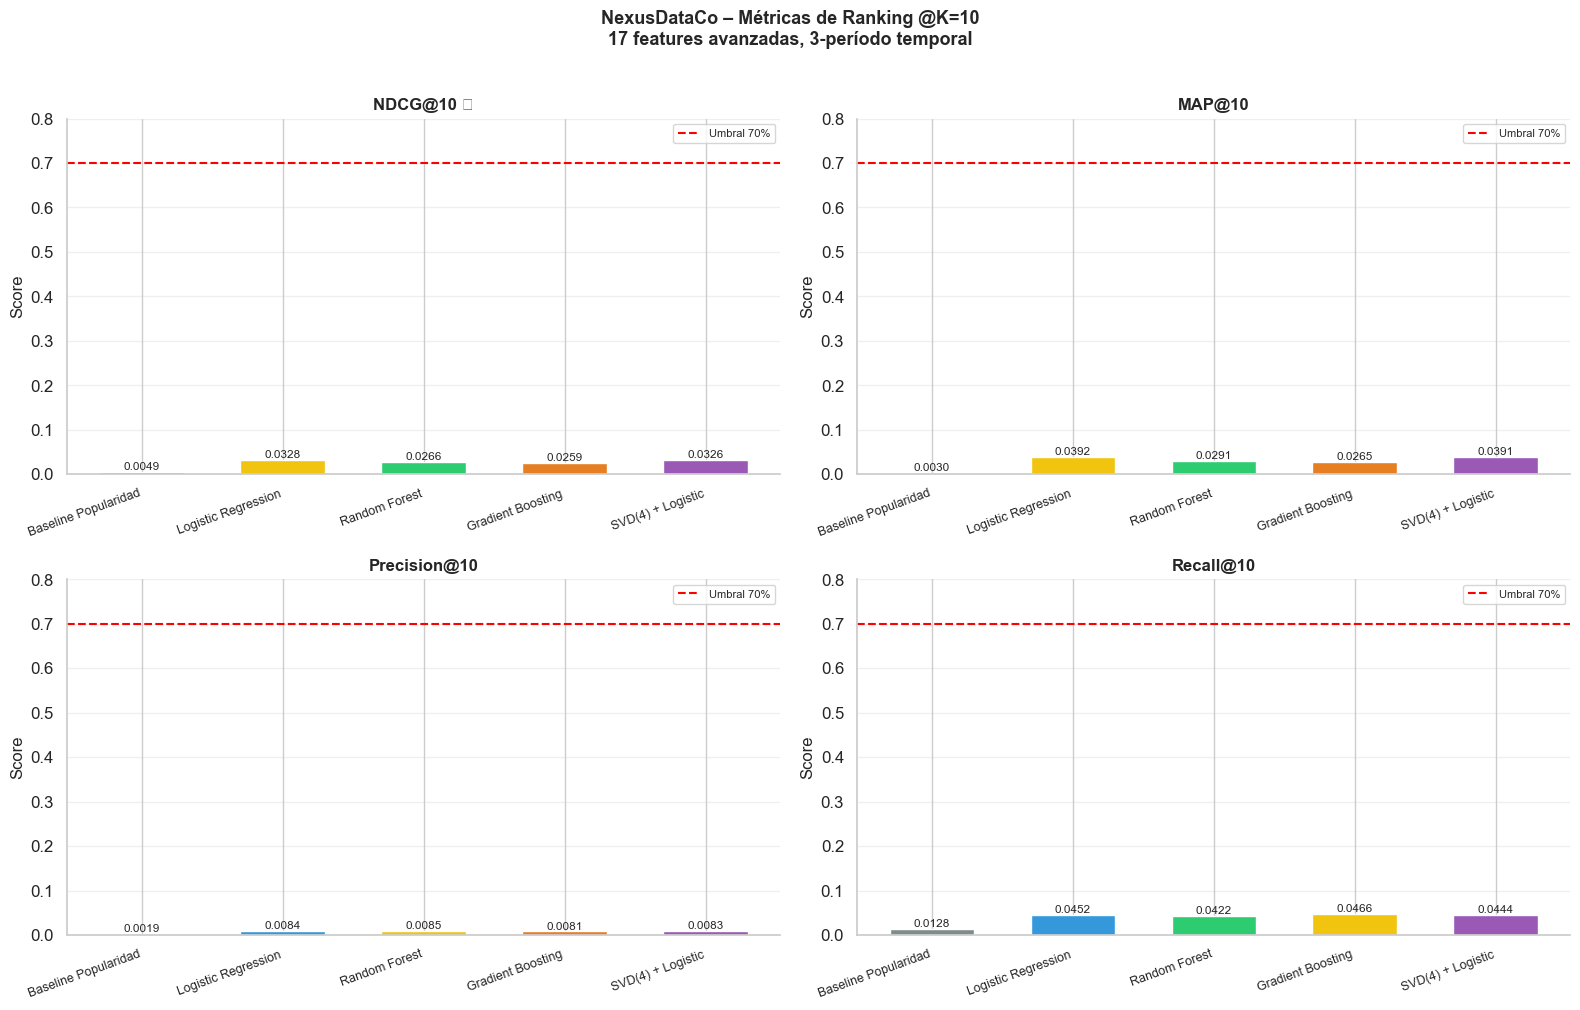

✅ Guardado: reports/ranking_metrics_k10.png


In [11]:
short   = lambda n: n.split('.')[1].strip()[:26]
palette = ['#7f8c8d','#3498db','#2ecc71','#e67e22','#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
metric_cols = [f'NDCG@{K_MAIN}',f'MAP@{K_MAIN}',f'P@{K_MAIN}',f'R@{K_MAIN}']
titles      = ['NDCG@10 ⭐', 'MAP@10', 'Precision@10', 'Recall@10']
snames      = [short(n) for n in df_k.index]

for ax, col, title in zip(axes, metric_cols, titles):
    vals   = df_k[col].values
    best_i = int(np.argmax(vals))
    colors = ['#f1c40f' if i==best_i else palette[i] for i in range(len(vals))]
    bars   = ax.bar(range(len(snames)), vals, color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(snames)))
    ax.set_xticklabels(snames, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(vals.max()*1.2, 0.80))
    ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    ax.axhline(0.70, color='red', ls='--', lw=1.5, label='Umbral 70%')
    off = vals.max()*0.015
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+off,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8.5)
    ax.legend(fontsize=8)

plt.suptitle('NexusDataCo – Métricas de Ranking @K=10\n17 features avanzadas, 3-período temporal',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/ranking_metrics_k10.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reports/ranking_metrics_k10.png')

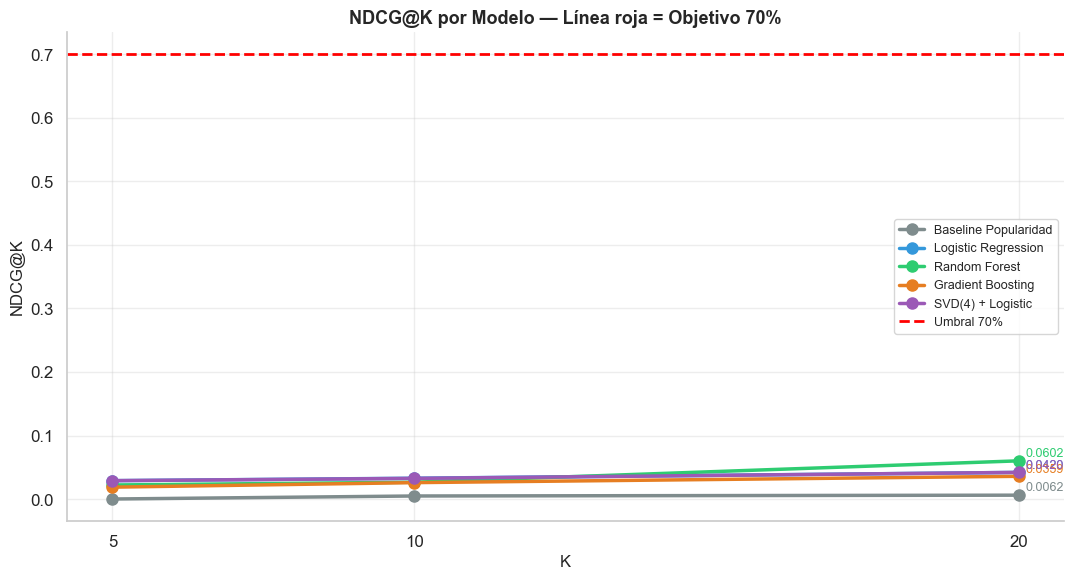

✅ Guardado: reports/ndcg_curve.png


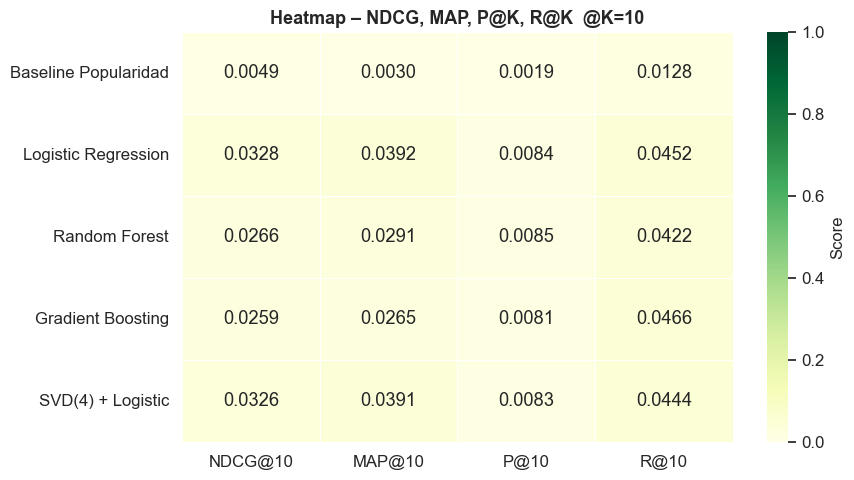

✅ Guardado: reports/ranking_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
for idx, (mn, _) in enumerate(MODELS):
    sub = df_all[df_all['Modelo']==mn].sort_values('K')
    ax.plot(sub['K'].values, sub['NDCG'].values, marker='o', lw=2.5,
            ms=8, color=palette[idx], label=short(mn))
    ax.annotate(f'{sub["NDCG"].iloc[-1]:.4f}', (sub['K'].iloc[-1], sub['NDCG'].iloc[-1]),
                textcoords='offset points', xytext=(5,3), fontsize=9, color=palette[idx])
ax.axhline(0.70, color='red', ls='--', lw=2, label='Umbral 70%')
ax.set_xticks(K_VALUES)
ax.set_xlabel('K', fontsize=12); ax.set_ylabel('NDCG@K', fontsize=12)
ax.set_title('NDCG@K por Modelo — Línea roja = Objetivo 70%', fontweight='bold', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('../reports/ndcg_curve.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Guardado: reports/ndcg_curve.png')

# Heatmap
fig, ax = plt.subplots(figsize=(9, 5))
heat = df_k.copy(); heat.index = [short(n) for n in heat.index]
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Score'}, vmin=0, vmax=1)
ax.set_title(f'Heatmap – NDCG, MAP, P@K, R@K  @K={K_MAIN}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Guardado: reports/ranking_heatmap.png')

## 🏆 Conclusiones

In [13]:
df_rank = df_k.sort_values(f'NDCG@{K_MAIN}', ascending=False)
best    = df_rank.index[0]
print('='*65)
print(f'  🏆 MODELO GANADOR: {best}')
for col in df_rank.columns:
    pct = df_rank.loc[best, col]*100
    flag = '✅' if pct >= 70 else '⚠️'
    print(f'  {flag}  {col:12s} = {df_rank.loc[best, col]:.4f}  ({pct:.1f}%)')
print('='*65)
print('\n📊 Todos los modelos:')
print(df_rank.to_string())

df_all.to_csv('../reports/ndcg_results.csv', index=False)
model_obj_map = {
    '1. Baseline Popularidad': None,
    '2. Logistic Regression' : lr,
    '3. Random Forest'       : rf,
    '4. Gradient Boosting'   : gb,
    '5. SVD(4) + Logistic'   : svd_pipe,
}
best_obj = model_obj_map.get(best)
if best_obj is not None:
    os.makedirs('../models', exist_ok=True)
    joblib.dump(best_obj, '../models/best_model_ndcg.pkl')
    print(f'\n✅ Modelo guardado: models/best_model_ndcg.pkl')
print('✅ CSV guardado: reports/ndcg_results.csv')

  🏆 MODELO GANADOR: 2. Logistic Regression
  ⚠️  NDCG@10      = 0.0328  (3.3%)
  ⚠️  MAP@10       = 0.0392  (3.9%)
  ⚠️  P@10         = 0.0084  (0.8%)
  ⚠️  R@10         = 0.0452  (4.5%)

📊 Todos los modelos:
                         NDCG@10  MAP@10    P@10    R@10
Modelo                                                  
2. Logistic Regression    0.0328  0.0392  0.0084  0.0452
5. SVD(4) + Logistic      0.0326  0.0391  0.0083  0.0444
3. Random Forest          0.0266  0.0291  0.0085  0.0422
4. Gradient Boosting      0.0259  0.0265  0.0081  0.0466
1. Baseline Popularidad   0.0049  0.0030  0.0019  0.0128

✅ Modelo guardado: models/best_model_ndcg.pkl
✅ CSV guardado: reports/ndcg_results.csv
